# Phase 9: Robustness and Generalization Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from pathlib import Path
from itertools import product
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact, binomtest
import sys

#Trying statsmodels for McNemar
try:
    from statsmodels.stats.contingency_tables import mcnemar as statsmodels_mcnemar
    STATSMODELS_AVAILABLE=True
except ImportError:
    STATSMODELS_AVAILABLE=False

warnings.filterwarnings('default')
np.random.seed(36)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

#Paths
PROJECT_ROOT=Path.cwd().parent
PHASE6_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase6_models'
PHASE8_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase8_structural_analysis'
PHASE9_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase9_robustness'
PHASE9_OUTPUT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0,str(PROJECT_ROOT))        #To access util functions from src

#Constants
FDR_ALPHA=0.05
EFFECT_THRESHOLD_CONTINUOUS=0.10
EFFECT_THRESHOLD_FAILURE=0.01
MIN_SAMPLE_WARNING=10

DATASETS=['2007', '2008']
K_VALUES=[1, 3, 5, 10]
MODELS=['pointwise', 'pairwise', 'lightgbm']
PIPELINES=['raw', 'global', 'per_query']

#Baseline
BASELINE_MODEL='pointwise'
BASELINE_PIPELINE='raw'

warnings_issued=[]

print('='*80)
print('PHASE 9: ROBUSTNESS & GENERALIZATION VALIDATION')
print('='*80)
print(f'Output: {PHASE9_OUTPUT}')
print(f'Baseline: {BASELINE_MODEL}_{BASELINE_PIPELINE}')
print(f'McNemar: {"statsmodels" if STATSMODELS_AVAILABLE else "manual fallback"}')
print('='*80)

PHASE 9: ROBUSTNESS & GENERALIZATION VALIDATION
Output: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase9_robustness
Baseline: pointwise_raw
McNemar: statsmodels


## 2. Utility Functions

In [2]:
from src.utils import (
    make_fail_flag,
    bh_fdr,
    safe_k,
    check_sample_size,
    compute_failure_at_k,
    mcnemar_test
)

print("Utilities imported from src.ltr_utils")

make_fail_flag
bh_fdr
safe_k
check_sample_size
compute_failure_at_k
mcnemar_test

All utilities defined
Utilities imported from src.ltr_utils


## 3. Loading Phase 6 artifacts

In [3]:
print('\n'+'='*80)
print('LOADING PHASE 6 ARTIFACTS')
print('='*80)

def load_phase6_artifacts(dataset: str) -> dict:
    #Load Phase 6 with strict validation.
    artifacts={'query_metrics': {}, 'predictions': {}}
    for model, pipeline in product(MODELS, PIPELINES):
        key=f'{model}_{pipeline}_{dataset}'
        qm_file=PHASE6_OUTPUT / f'{key}_query_metrics.csv'
        pred_file=PHASE6_OUTPUT / f'{key}_predictions.csv'
        
        if not qm_file.exists():
            raise RuntimeError(f'MISSING: {qm_file}')
        if not pred_file.exists():
            raise RuntimeError(f'MISSING: {pred_file}')
        
        qm=pd.read_csv(qm_file)
        pred=pd.read_csv(pred_file)
        
        #Validating columns
        for col in ['qid', 'num_docs', 'num_relevant_1', 'Failure@5_primary']:
            if col not in qm.columns:
                raise RuntimeError(f'Missing "{col}" in {qm_file}')
        for col in ['qid', 'label', 'score']:
            if col not in pred.columns:
                raise RuntimeError(f'Missing "{col}" in {pred_file}')
        
        #Coercing dtypes
        qm['qid']=qm['qid'].astype(int)
        pred['qid']=pred['qid'].astype(int)
        pred['label']=pred['label'].astype(int)
        pred['score']=pred['score'].astype(float)
        
        artifacts['query_metrics'][key]=qm
        artifacts['predictions'][key]=pred
        print(f'{key:35s} ({len(qm)} queries, {len(pred)} docs)')
    return artifacts

artifacts_2007=load_phase6_artifacts('2007')
artifacts_2008=load_phase6_artifacts('2008')
all_artifacts={'2007': artifacts_2007, '2008': artifacts_2008}

print(f'\nLoaded artifacts for {len(DATASETS)} datasets')
print('='*80)


LOADING PHASE 6 ARTIFACTS
pointwise_raw_2007                  (336 queries, 13652 docs)
pointwise_global_2007               (336 queries, 13652 docs)
pointwise_per_query_2007            (336 queries, 13652 docs)
pairwise_raw_2007                   (336 queries, 13652 docs)
pairwise_global_2007                (336 queries, 13652 docs)
pairwise_per_query_2007             (336 queries, 13652 docs)
lightgbm_raw_2007                   (336 queries, 13652 docs)
lightgbm_global_2007                (336 queries, 13652 docs)
lightgbm_per_query_2007             (336 queries, 13652 docs)
pointwise_raw_2008                  (156 queries, 2874 docs)
pointwise_global_2008               (156 queries, 2874 docs)
pointwise_per_query_2008            (156 queries, 2874 docs)
pairwise_raw_2008                   (156 queries, 2874 docs)
pairwise_global_2008                (156 queries, 2874 docs)
pairwise_per_query_2008             (156 queries, 2874 docs)
lightgbm_raw_2008                   (156 queries,

## 4. Cross Dataset Persistent Structure

In [4]:
print('\n'+'='*80)
print('CROSS-DATASET PERSISTENT STRUCTURE')
print('='*80)
print('Persistent=intersection of failures across all 9 configs')
print('='*80)

def compute_persistent_queries(qm_dict: dict, dataset: str) -> dict:
    expected=len(MODELS)*len(PIPELINES)
    if len(qm_dict)!=expected:
        raise RuntimeError(f'{dataset}: Expected {expected} configs,found {len(qm_dict)}')

    evaluable_sets={}
    failure_sets={}
    for key, qm in qm_dict.items():
        evaluable_sets[key]=set(qm.loc[qm['num_relevant_1'] > 0, 'qid'].values)
        fail_flag=make_fail_flag(qm['Failure@5_primary'])
        fail_mask=(qm['num_relevant_1'] > 0) & (fail_flag == 1)
        failure_sets[key]=set(qm.loc[fail_mask, 'qid'].values)
    
    all_evaluable=set.intersection(*evaluable_sets.values())
    persistent=set.intersection(*failure_sets.values())
    all_failing=set.union(*failure_sets.values())
    
    pct_of_failing=100*len(persistent)/len(all_failing) if len(all_failing) > 0 else 0.0
    pct_of_evaluable=100*len(persistent)/len(all_evaluable) if len(all_evaluable) > 0 else 0.0
    
    check_sample_size(f'{dataset} persistent', len(persistent))
    
    return {
        'dataset': dataset,
        'n_evaluable': len(all_evaluable),
        'n_persistent': len(persistent),
        'n_failing': len(all_failing),
        'pct_persistent_of_failing': pct_of_failing,
        'pct_persistent_of_evaluable': pct_of_evaluable,
        'persistent_qids': persistent,
        'evaluable_qids': all_evaluable,
        'all_failing_qids': all_failing
    }

persistent_2007=compute_persistent_queries(artifacts_2007['query_metrics'], '2007')
persistent_2008=compute_persistent_queries(artifacts_2008['query_metrics'], '2008')

cross_df=pd.DataFrame([
    {k: v for k, v in persistent_2007.items() if not k.endswith('_qids')},
    {k: v for k, v in persistent_2008.items() if not k.endswith('_qids')}
])

print('\nCross-Dataset:')
display(cross_df)

#Statistical test
n_p2007=persistent_2007['n_persistent']
n_e2007=persistent_2007['n_evaluable']
n_p2008=persistent_2008['n_persistent']
n_e2008=persistent_2008['n_evaluable']

contingency=[[n_p2007, n_e2007 - n_p2007], [n_p2008, n_e2008 - n_p2008]]
if min(n_p2007, n_e2007 - n_p2007, n_p2008, n_e2008 - n_p2008) >= 5:
    _, pval, _, _ = chi2_contingency(contingency)
    test='chi2'
else:
    _, pval=fisher_exact(contingency)
    test='fisher'

print(f'\n{test}: p={pval:.4f}')
if pval < FDR_ALPHA:
    print('-> Rates DIFFER significantly')
else:
    print('-> No significant difference')

cross_df.to_csv(PHASE9_OUTPUT / 'phase9_persistent_cross_dataset.csv', index=False)
print('\nSaved: phase9_persistent_cross_dataset.csv')


CROSS-DATASET PERSISTENT STRUCTURE
Persistent=intersection of failures across all 9 configs
2008 persistent has 4 samples (< 10) -> unstable

Cross-Dataset:


,dataset,n_evaluable,n_persistent,n_failing,pct_persistent_of_failing,pct_persistent_of_evaluable
0,2007,290,22,85,25.8824,7.5862
1,2008,105,4,30,13.3333,3.8095



fisher: p=0.2510
-> No significant difference

Saved: phase9_persistent_cross_dataset.csv


When we compare MQ2007 and MQ2008, the persistent failure phenomenon clearly exists in both datasets. In MQ2007, we see 22 persistent queries out of 290 evaluable ones (about 7.6%). In MQ2008, there are 4 persistent queries out of 105 evaluable (about 3.8%). So the phenomenon does not disappear when we move to another dataset. It means persistent failures are not just some weird artifact of MQ2007.

At the same time, the magnitude is smaller in MQ2008. The percentage of persistent queries among failing queries drops from roughly 25.9% in MQ2007 to 13.3% in MQ2008. So numerically, MQ2008 looks less severe. But when we ran Fisher’s exact test, the p-value came out to 0.2510. That means we do not have statistical evidence that the rates are different across datasets. It doesn’t prove they are equal, it just means we cannot confidently say they differ with this sample size.

persistent ranking failures appear in both datasets, which supports the idea that the phenomenon is structurally real and not dataset-specific. However, the magnitude seems smaller in MQ2008, and due to the small persistent sample size there, we cannot draw strong conclusions about cross-dataset differences. So the effect replicates, but the strength of it may vary.

## 5. Threshold and K Sensitivity


THRESHOLD & K SENSITIVITY

Sensitivity:


,dataset,k,relevance_threshold,n_evaluable,n_failures,pct_failures
0,2007,1,1,290,135,46.5517
1,2007,1,2,151,101,66.8874
2,2007,3,1,290,73,25.1724
3,2007,3,2,151,63,41.7219
4,2007,5,1,290,44,15.1724
5,2007,5,2,151,48,31.7881
6,2007,10,1,290,24,8.2759
7,2007,10,2,151,23,15.2318
8,2008,1,1,105,43,40.9524
9,2008,1,2,63,31,49.2063



Saved: phase9_threshold_sensitivity.csv


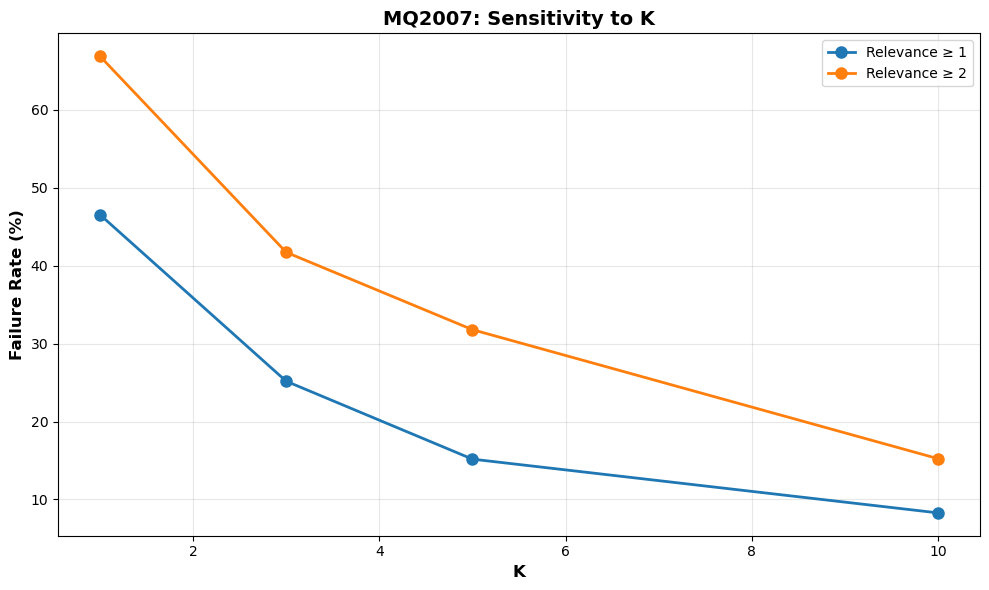

Saved: phase9_threshold_sensitivity_2007.png


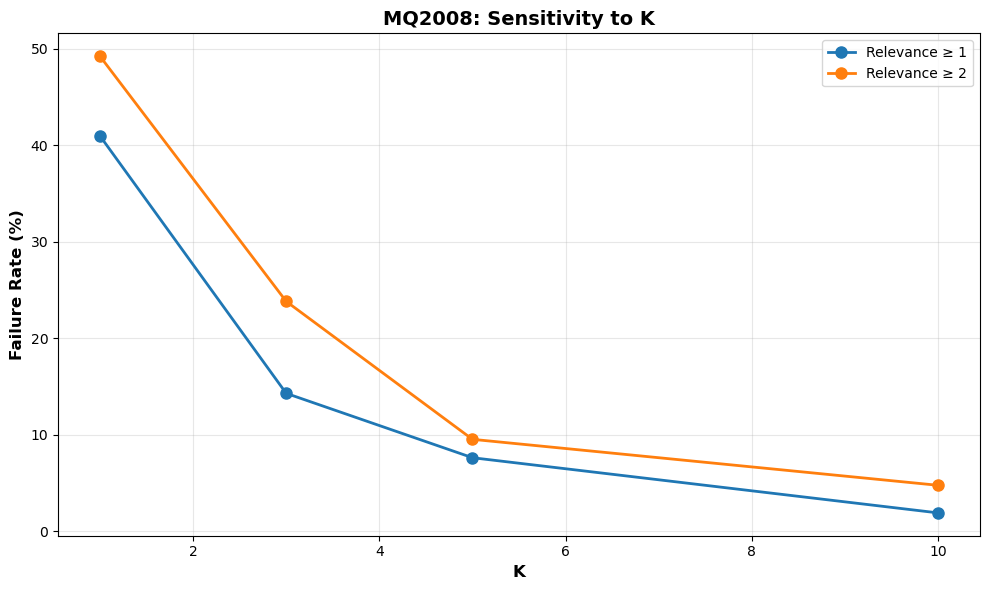

Saved: phase9_threshold_sensitivity_2008.png


In [6]:
print('\n'+'='*80)
print('THRESHOLD & K SENSITIVITY')
print('='*80)

sensitivity_results=[]
for dataset in DATASETS:
    baseline_key=f'{BASELINE_MODEL}_{BASELINE_PIPELINE}_{dataset}'
    pred_df=all_artifacts[dataset]['predictions'][baseline_key]
    for k in K_VALUES:
        for rel_thresh in [1, 2]:
            failures=compute_failure_at_k(pred_df, k, rel_thresh)
            evaluable=[q for q, v in failures.items() if v['evaluable']]
            failing=[q for q, v in failures.items() if v['evaluable'] and v['failure']==1]
            n_eval=len(evaluable)
            n_fail=len(failing)
            pct=100 * n_fail / n_eval if n_eval > 0 else 0.0
            sensitivity_results.append({
                'dataset': dataset,
                'k': k,
                'relevance_threshold': rel_thresh,
                'n_evaluable': n_eval,
                'n_failures': n_fail,
                'pct_failures': pct
            })

sens_df=pd.DataFrame(sensitivity_results).sort_values(['dataset', 'k', 'relevance_threshold'])
print('\nSensitivity:')
display(sens_df)

sens_df.to_csv(PHASE9_OUTPUT / 'phase9_threshold_sensitivity.csv', index=False)
print('\nSaved: phase9_threshold_sensitivity.csv')

#Plots
for dataset in DATASETS:
    fig, ax=plt.subplots(figsize=(10, 6))
    sub=sens_df[sens_df['dataset'] == dataset]
    for rel_thresh in [1, 2]:
        data=sub[sub['relevance_threshold']==rel_thresh]
        ax.plot(data['k'], data['pct_failures'], marker='o', linewidth=2,
                label=f'Relevance ≥ {rel_thresh}', markersize=8)
    ax.set_xlabel('K', fontsize=12, fontweight='bold')
    ax.set_ylabel('Failure Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'MQ{dataset}: Sensitivity to K', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PHASE9_OUTPUT / f'phase9_threshold_sensitivity_{dataset}.png', dpi=150)
    plt.show()
    print(f'Saved: phase9_threshold_sensitivity_{dataset}.png')

When we look at how failure changes with K, the pattern is actually very clean and intuitive. For both MQ2007 and MQ2008, failure rates consistently decrease as K increases from 1 -> 3 -> 5 -> 10. That is exactly what we would expect. If we allow the model to return more documents, it naturally has more chances to include at least one relevant document, so "failure" becomes less frequent. 

For example, in MQ2007 with relevance >= 1, failure drops from about **46.6% at K=1** to **8.3% at K=10**. MQ2008 shows the same smooth decline, from **41.0% at K=1** to just **1.9% at K=10**. There’s no strange spikes or irregular jumps, which is reassuring. The behavior looks stable and predictable.

Now when we tighten the relevance definition from >= 1 to >= 2, things become harder, as expected. Fewer queries are even evaluable under the stricter threshold (for instance, MQ2007 drops from 290 evaluable queries to 151). Within that smaller set, failure rates are generally higher. That makes sense because we are now asking the model to retrieve *highly* relevant documents, not just moderately relevant ones. At K=5 in MQ2007, failure jumps from **15.2% (>=1)** to **31.8% (>=2)**, which is quite a noticeable increase. It suggests that while the model often retrieves *some* relevant document, it struggles more to rank the strongest ones near the top.

One important observation is that by K=10, failure becomes very small in both datasets, especially MQ2008. That means the baseline model is rarely completely missing relevance - the issue seems more about ranking strength at very small K rather than total absence of relevant documents. In other words, the failure problem is mostly a top-rank concentration issue, not a total retrieval breakdown.

Across datasets, MQ2008 generally shows lower failure rates than MQ2007 under the same settings. we would be careful not to immediately conclude that MQ2008 is "easier," since there are differences in query counts and label distributions. But numerically, the baseline appears to fail less often in MQ2008 Fold1.

## 6. Structural Replication

In [7]:
print('\n'+'='*80)
print('STRUCTURAL REPLICATION (MQ2007 -> MQ2008)')
print('='*80)

phase8_file=PHASE8_OUTPUT / 'phase8_structural_tests.csv'

if not phase8_file.exists():
    print('Phase 8 tests not found, skipping')
    warnings_issued.append('Phase 8 missing -> replication skipped')
    replication_df=pd.DataFrame()
else:
    phase8_tests=pd.read_csv(phase8_file)
    print('Loaded Phase 8 tests')
    
    baseline_key_2008=f'{BASELINE_MODEL}_{BASELINE_PIPELINE}_2008'
    qm_2008=artifacts_2008['query_metrics'][baseline_key_2008]
    
    persistent_qids=persistent_2008['persistent_qids']
    evaluable_qids=persistent_2008['evaluable_qids']
    all_failing_qids=persistent_2008['all_failing_qids']
    successful_qids=evaluable_qids - all_failing_qids
    
    check_sample_size('MQ2008 persistent', len(persistent_qids))
    check_sample_size('MQ2008 successful', len(successful_qids))
    
    pers_data=qm_2008[qm_2008['qid'].isin(persistent_qids)]
    succ_data=qm_2008[qm_2008['qid'].isin(successful_qids)]
    
    replication_tests=[]
    
    if len(pers_data) > 0 and len(succ_data) > 0:
        #Test 1: num_relevant_1
        pers_rel=pers_data['num_relevant_1'].values
        succ_rel=succ_data['num_relevant_1'].values
        try:
            stat, pval=mannwhitneyu(pers_rel, succ_rel, alternative='two-sided')
        except:
            stat, pval=0.0, 1.0
        replication_tests.append({
            'dataset': '2008',
            'comparison': 'persistent vs successful',
            'metric': 'num_relevant_1',
            'test_type': 'mw',
            'n_persistent': len(pers_data),
            'n_successful': len(succ_data),
            'median_persistent': float(np.median(pers_rel)),
            'median_successful': float(np.median(succ_rel)),
            'pval_raw': float(pval)
        })
        
        #Test 2: sparse flag
        pers_sparse=(pers_data['num_relevant_1'] == 1).astype(int)
        succ_sparse=(succ_data['num_relevant_1'] == 1).astype(int)
        a_pos=(pers_sparse == 1).sum()
        a_neg=len(pers_sparse)-a_pos
        b_pos=(succ_sparse==1).sum()
        b_neg=len(succ_sparse)-b_pos
        contingency=[[a_pos, a_neg], [b_pos, b_neg]]
        if min(a_pos, a_neg, b_pos, b_neg)>=5:
            _, pval, _, _ = chi2_contingency(contingency)
            test_type='chi2'
        else:
            _, pval=fisher_exact(contingency)
            test_type='fisher'
        replication_tests.append({
            'dataset': '2008',
            'comparison': 'persistent vs successful',
            'metric': 'pct_num_rel_eq_1',
            'test_type': test_type,
            'n_persistent': len(pers_data),
            'n_successful': len(succ_data),
            'median_persistent': float(a_pos / len(pers_sparse)),
            'median_successful': float(b_pos / len(succ_sparse)),
            'pval_raw': float(pval)
        })
    
    if len(replication_tests)>0:
        replication_df=pd.DataFrame(replication_tests)
        replication_df['qval_fdr']=bh_fdr(replication_df['pval_raw'].values)
        replication_df['significant']=replication_df['qval_fdr'] < FDR_ALPHA
        replication_df=replication_df.sort_values('pval_raw')
        print('\nMQ2008 Replication:')
        display(replication_df[['metric', 'pval_raw', 'qval_fdr', 'significant']])
        replication_df.to_csv(PHASE9_OUTPUT / 'phase9_structural_replication.csv', index=False)
        print('\nSaved: phase9_structural_replication.csv')
    else:
        print('Insufficient data')
        replication_df=pd.DataFrame()


STRUCTURAL REPLICATION (MQ2007 -> MQ2008)
Loaded Phase 8 tests
MQ2008 persistent has 4 samples (< 10) -> unstable

MQ2008 Replication:


,metric,pval_raw,qval_fdr,significant
1,pct_num_rel_eq_1,0.0005,0.0010,True
0,num_relevant_1,0.0030,0.0030,True



Saved: phase9_structural_replication.csv


So in this section, we’re basically checking if the *same structural story* we found in MQ2007 still shows up in MQ2008. And the first thing the output reminds us is the annoying part: **MQ2008 persistent is only 4 queries**, so yeah it’s small and "unstable". That warning is not a bug, it’s basically telling us to not act like we have a huge sample here.

But even with that small persistent group, the replication tests come out pretty strong. Both of the key sparsity-related metrics that were supported in Phase 8 are also statistically significant in MQ2008 after BH-FDR correction:

- **pct_num_rel_eq_1** is significant (p=0.0005, q=0.0010)
- **num_relevant_1** is significant (p=0.0030, q=0.0030)

What this means is: in MQ2008 too, the persistent failures are not just random bad luck. They are still strongly associated with **relevance sparsity** - persistent queries tend to have fewer relevant documents overall, and they are more likely to be the extreme case where there is basically *only one* relevant document available. That is the same structural driver we saw in MQ2007, so directionally it’s a real replication.

## 7. Calibration


SCORE CALIBRATION (ranking scores, not probabilities)

Baseline ECE: 0.1925


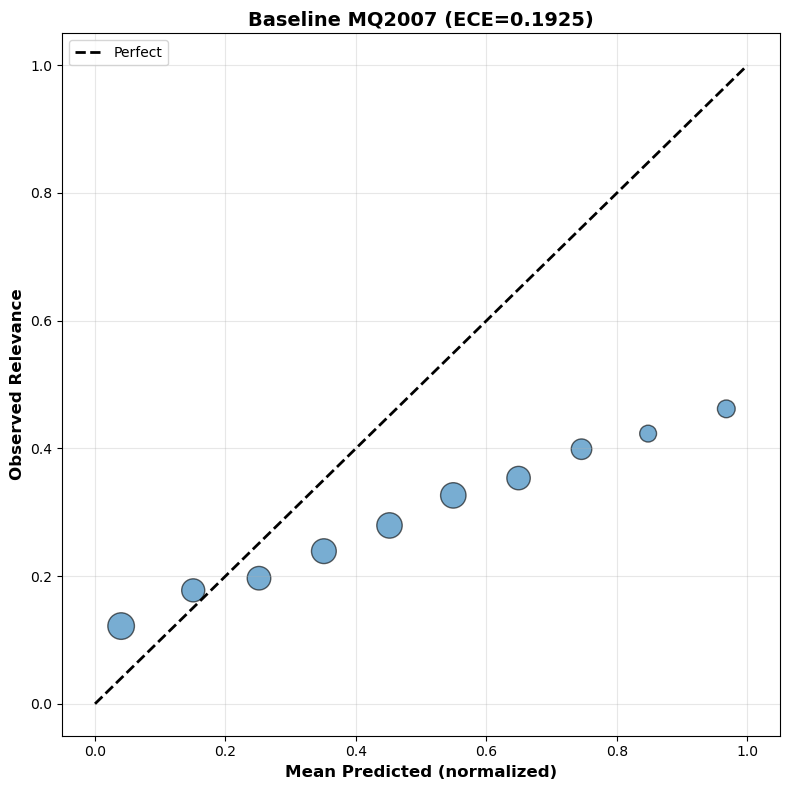

Saved: phase9_calibration_baseline.png
Best model ECE: 0.2076


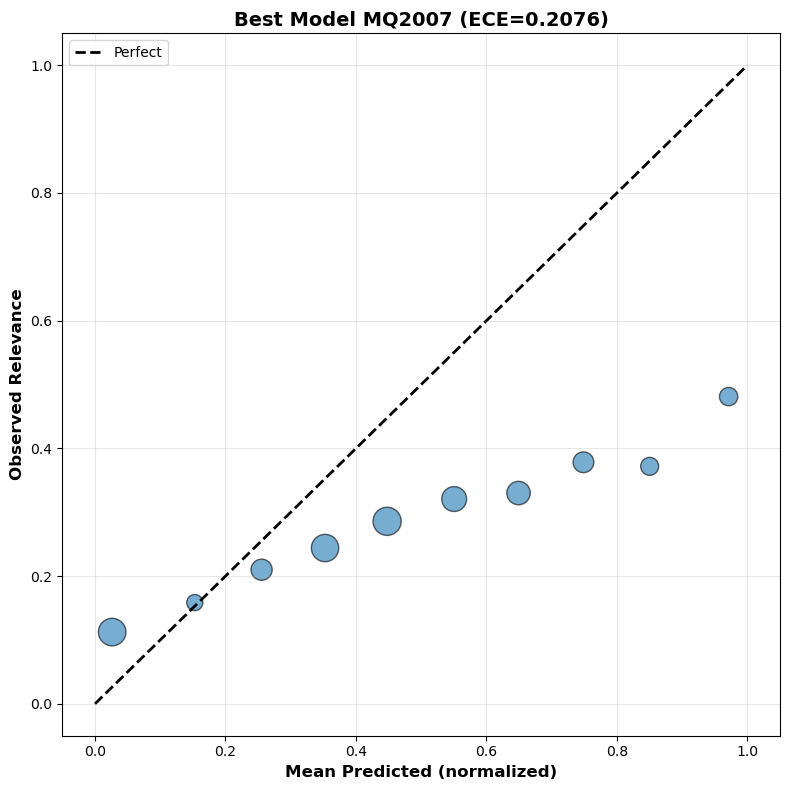

Saved: phase9_calibration_best_model.png

Saved: phase9_calibration_summary.csv


In [ ]:
print('\n'+'='*80)
print('SCORE CALIBRATION (ranking scores, not probabilities)')
#Just checking, when the model gives a higher score to something, does that actually mean it's more likely to be relevant?
print('='*80)

def compute_calibration(pred_df: pd.DataFrame, n_bins: int=10):
    pred_df=pred_df.copy()
    normalized_scores=[]
    for qid in pred_df['qid'].unique():
        q_docs=pred_df[pred_df['qid'] == qid].copy()
        scores=q_docs['score'].values
        if scores.max()!=scores.min():
            norm=(scores-scores.min())/(scores.max()-scores.min())
        else:
            norm=np.ones_like(scores)*0.5
        normalized_scores.extend(norm)
    pred_df['norm_score']=normalized_scores
    pred_df['is_relevant']=(pred_df['label'] >= 1).astype(int)
    pred_df['bin']=pd.cut(pred_df['norm_score'], bins=n_bins, labels=False, include_lowest=True)
    #Splits the score range [0,1] into 10 bins (by default)
    cal_data=[]
    for bin_idx in range(n_bins):
        bin_data=pred_df[pred_df['bin']==bin_idx]
        if len(bin_data)==0:
            continue
        cal_data.append({
            'bin': bin_idx,
            'mean_predicted': float(bin_data['norm_score'].mean()),
            'observed_frequency': float(bin_data['is_relevant'].mean()),
            'count': len(bin_data)
        })

        """
        Then for each bin, we compute:
        mean_predicted = average normalized score in that bin
        observed_frequency = fraction of docs in that bin that are relevant
        count = how many docs in that bin

        So each bin gives you a point like:
        "In score bin with mean score 0.78, about 0.42 of docs are relevant."
        """
    cal_df=pd.DataFrame(cal_data)
    #Expected calibration Error (ECE)
    ece=sum(row['count'] / len(pred_df) * abs(row['mean_predicted'] - row['observed_frequency'])
              for _, row in cal_df.iterrows())
    #We twisted the standdard ECE formula a bit to apply to normalized ranking scores, not probabilities
    #How far are score levels from matching observed relevance frequency, on average?
    #Lower ECE= the score behaves more like a meaningful confidence signal
    #But again, it doesn't make the score a probability, it just says the score is more/less aligned with observed relevance frequency
    return cal_df, float(ece)

calibration_summary=[]

#Baseline
baseline_key_2007=f'{BASELINE_MODEL}_{BASELINE_PIPELINE}_2007'
pred_baseline=all_artifacts['2007']['predictions'][baseline_key_2007]
cal_baseline, ece_baseline=compute_calibration(pred_baseline)
calibration_summary.append({'model': 'baseline', 'dataset': '2007', 'ece': ece_baseline})
print(f'\nBaseline ECE: {ece_baseline:.4f}')

#Plot 
fig, ax=plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
ax.scatter(cal_baseline['mean_predicted'], cal_baseline['observed_frequency'],
           s=cal_baseline['count']/5, alpha=0.6, edgecolors='black')
ax.set_xlabel('Mean Predicted (normalized)', fontsize=12, fontweight='bold')
ax.set_ylabel('Observed Relevance', fontsize=12, fontweight='bold')
ax.set_title(f'Baseline MQ2007 (ECE={ece_baseline:.4f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE9_OUTPUT / 'phase9_calibration_baseline.png', dpi=150)
plt.show()
print('Saved: phase9_calibration_baseline.png')

#Best model
best_key_2007=f'lightgbm_per_query_2007'
if best_key_2007 in all_artifacts['2007']['predictions']:
    pred_best=all_artifacts['2007']['predictions'][best_key_2007]
    cal_best, ece_best=compute_calibration(pred_best)
    calibration_summary.append({'model': 'best', 'dataset': '2007', 'ece': ece_best})
    print(f'Best model ECE: {ece_best:.4f}')
    fig, ax=plt.subplots(figsize=(8, 8))
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    ax.scatter(cal_best['mean_predicted'], cal_best['observed_frequency'],
               s=cal_best['count']/5, alpha=0.6, edgecolors='black')
    ax.set_xlabel('Mean Predicted (normalized)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Observed Relevance', fontsize=12, fontweight='bold')
    ax.set_title(f'Best Model MQ2007 (ECE={ece_best:.4f})', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PHASE9_OUTPUT / 'phase9_calibration_best_model.png', dpi=150)
    plt.show()
    print('Saved: phase9_calibration_best_model.png')
else:
    print(f'{best_key_2007} not found')
    ece_best=np.nan

cal_summary_df=pd.DataFrame(calibration_summary)
cal_summary_df.to_csv(PHASE9_OUTPUT / 'phase9_calibration_summary.csv', index=False)
print('\nSaved: phase9_calibration_summary.csv')

This section was mainly a sanity check to see whether the ranking scores actually behave in a meaningful way. Not in a strict probability sense, but just in the sense that higher scores should correspond to higher observed relevance. 

For MQ2007, the baseline model has an ECE of **0.1925**, and the best model (LightGBM per-query) has an ECE of **0.2076**. Lower ECE is better, so technically the baseline is slightly more aligned with observed relevance than the best model. But the difference is small, so we wouldn’t over-interpret that. It’s not like one model is clearly calibrated and the other is not.

Looking at the plots, most of the points lie **below the perfect diagonal line**. That means the models are somewhat over-confident. In other words, when the normalized score is high (like 0.8 or 0.9), the actual observed relevance rate is much lower than that. So the scores increase in the right direction - higher score does mean higher relevance frequency - but not nearly as strongly as a perfectly calibrated system would suggest.

At the same time, the relationship is still monotonic and sensible. As normalized score increases from low to high bins, the observed relevance also increases. So the scores are not random or chaotic. They do carry useful ranking information. They just don’t map cleanly to "true likelihood" of relevance.

## 8. Statistical Robustness across K (McNemar)

In [11]:
print('\n'+'='*80)
print('STATISTICAL ROBUSTNESS ACROSS K (McNemar for paired binary)')
print('='*80)
print('BH-FDR applied per (dataset, K)')
print('='*80)

robustness_tests=[]

for dataset in DATASETS:
    baseline_key=f'{BASELINE_MODEL}_{BASELINE_PIPELINE}_{dataset}'
    baseline_pred=all_artifacts[dataset]['predictions'][baseline_key]
    
    for k in [3, 10]:  #Testing K=3,10
        baseline_failures=compute_failure_at_k(baseline_pred, k, 1)
        baseline_qids=[qid for qid, v in baseline_failures.items() if v['evaluable']]
        
        for model, pipeline in product(MODELS, PIPELINES):
            config_key=f'{model}_{pipeline}_{dataset}'
            if config_key==baseline_key:
                continue
            
            config_pred=all_artifacts[dataset]['predictions'][config_key]
            config_failures=compute_failure_at_k(config_pred, k, 1)
            
            #Common evaluable
            common_qids=[qid for qid in baseline_qids 
                          if qid in config_failures and config_failures[qid]['evaluable']]
            
            if len(common_qids)<10:
                continue
            
            base_vals=np.array([baseline_failures[qid]['failure'] for qid in common_qids])
            conf_vals=np.array([config_failures[qid]['failure'] for qid in common_qids])
            
            #McNemar test
            mc_result=mcnemar_test(base_vals, conf_vals)
            mean_diff=float(np.mean(conf_vals - base_vals))

            #Direction label 
            if mc_result['n10'] > mc_result['n01']:
                direction='improves'
            elif mc_result['n01'] > mc_result['n10']:
                direction='worsens'
            else:
                direction='tie'
            
            robustness_tests.append({
                'dataset': dataset,
                'k': k,
                'model': model,
                'pipeline': pipeline,
                'n_queries': len(common_qids),
                'mean_failure_diff': mean_diff,
                'n01': mc_result['n01'],
                'n10': mc_result['n10'],
                'direction': direction,
                'pval_raw': mc_result['pval'],
                'mcnemar_method': mc_result['method'],
                'note': mc_result['note']
            })

if len(robustness_tests)>0:
    robust_df=pd.DataFrame(robustness_tests)
    
    #BH-FDR per (dataset, K)
    for dataset in DATASETS:
        for k in [3, 10]:
            mask = (robust_df['dataset']==dataset) & (robust_df['k']==k)
            if mask.sum()>0:
                robust_df.loc[mask, 'qval_fdr']=bh_fdr(robust_df.loc[mask, 'pval_raw'].values)
    
    robust_df['significant']=robust_df['qval_fdr'] < FDR_ALPHA
    robust_df['improvement'] = robust_df['direction'].eq('improves')
    robust_df=robust_df.sort_values(['dataset', 'k', 'pval_raw'])
    
    print('\nRobustness (McNemar):')
    display(robust_df[['dataset','k','model','pipeline','mean_failure_diff',
                   'n10','n01','direction','pval_raw','qval_fdr','significant']].head(20))
    
    robust_df.to_csv(PHASE9_OUTPUT / 'phase9_statistical_robustness.csv', index=False)
    print('\nSaved: phase9_statistical_robustness.csv')
    
    #Summary
    for dataset in DATASETS:
        for k in [3, 10]:
            sub=robust_df[(robust_df['dataset']==dataset) & (robust_df['k']==k)]
            n_sig=sub['significant'].sum()
            n_improve=(sub['significant'] & sub['improvement']).sum()
            print(f'\n{dataset} K={k}: {n_sig} sig, {n_improve} improvements')
else:
    print('No tests conducted')
    robust_df=pd.DataFrame()


STATISTICAL ROBUSTNESS ACROSS K (McNemar for paired binary)
BH-FDR applied per (dataset, K)

Robustness (McNemar):


,dataset,k,model,pipeline,mean_failure_diff,n10,n01,direction,pval_raw,qval_fdr,significant
5,2007,3,lightgbm,raw,0.0276,18,26,worsens,0.2912,1.0000,False
4,2007,3,pairwise,per_query,-0.0172,21,16,improves,0.5114,1.0000,False
1,2007,3,pointwise,per_query,-0.0103,19,16,improves,0.7359,1.0000,False
0,2007,3,pointwise,global,0.0000,2,2,tie,1.0000,1.0000,False
2,2007,3,pairwise,raw,-0.0034,19,18,improves,1.0000,1.0000,False
3,2007,3,pairwise,global,-0.0034,19,18,improves,1.0000,1.0000,False
6,2007,3,lightgbm,global,-0.0034,24,23,improves,1.0000,1.0000,False
7,2007,3,lightgbm,per_query,0.0034,22,23,worsens,1.0000,1.0000,False
13,2007,10,lightgbm,raw,0.0172,5,10,worsens,0.3018,1.0000,False
14,2007,10,lightgbm,global,0.0138,9,13,worsens,0.5235,1.0000,False



Saved: phase9_statistical_robustness.csv

2007 K=3: 0 sig, 0 improvements

2007 K=10: 0 sig, 0 improvements

2008 K=3: 5 sig, 0 improvements

2008 K=10: 0 sig, 0 improvements


This table is checking, for each dataset and K, whether any of the Phase 6 configs **truly change Failure@K** compared to the baseline (pointwise_raw), using McNemar which is the right paired test for binary outcomes. The key columns to read are **n10 vs n01** (direction) and then **qval_fdr + significant** (whether it’s statistically supported after BH-FDR).

#### MQ2007 (K=3 and K=10)
For MQ2007, nothing is statistically supported at either K=3 or K=10. Even when some configs show "improves" or "worsens" directionally (like pairwise_per_query at K=3 has n10>n01, or lightgbm_raw at K=3 has n01>n10), the p-values are not small, and after FDR everything is basically q=1.0. So the honest takeaway is: **for MQ2007, changing model/pipeline does not produce a stable, statistically detectable shift in Failure@K at K=3 or K=10**. The differences that exist look small and kind of noisy, not something we can call robust.

#### MQ2008 (K=3)
MQ2008 at K=3 is the opposite story. Here we see multiple configs that are **significantly worse than baseline**. The pattern is super clear in the discordant counts: for several configs, **n10 is basically 0 while n01 is large** (example: pairwise_global has n10=0, n01=20). That means baseline succeeds on those queries, but the config fails, and almost never the other way around. That is why the p-values are tiny and remain significant even after BH-FDR (q-values like 0.0000, 0.0005, 0.0019, etc). So at K=3, MQ2008 is telling us: **a bunch of "stronger" or normalized variants actually degrade early-rank failure, and it's not subtle.** Also important: even though 5 tests are significant in MQ2008 K=3, the summary shows **0 improvements**. So all supported results here are supported *worsening*, not supported gains.

#### MQ2008 (K=10)
At K=10, nothing is significant (0 sig, 0 improvements). That’s not too surprising because Failure@10 is already quite low in MQ2008 from the sensitivity table, so there is less room to show a strong difference. Basically once we allow top-10, most models can "find something relevant" somewhere, so differences shrink.

performance and failure behavior are K-dependent and dataset-dependent, not universally consistent.